In [1]:
from diffusers import StableDiffusionPipeline
import torch

In [2]:
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, safety_checker=None)
pipe = pipe.to("cuda")

prompt = "..."
image = pipe(prompt).images[0]  

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

c:\Users\henhen724\miniconda3\envs\diffusion_env\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\henhen724\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\henhen724\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or audit

  0%|          | 0/50 [00:00<?, ?it/s]

In [3]:
image.save("astronaut_rides_horse.png")

## ELS vs SDXL latent comparison
This section downloads an SDXL pipeline, builds a latent-space ELS machine, and compares SDXL images with ELS-evolved latents decoded through the SDXL VAE. Requires GPU and an SDXL checkpoint (default: `stabilityai/stable-diffusion-xl-base-1.0`).

In [1]:
# Minimal deps for SDXL + ELS
# Uncomment if not already installed in the environment
# pip install -q diffusers transformers accelerate safetensors
# pip install -q --upgrade huggingface_hub


In [2]:
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

from diffusers import StableDiffusionXLPipeline

from src.utils.idealscore import LocalEquivBordersScoreModule, ScheduledScoreMachine, cosine_noise_schedule

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id = "stabilityai/stable-diffusion-xl-base-1.0"  # change if you have another SDXL checkpoint
seed = 0
_ = torch.manual_seed(seed)


In [3]:
# Load SDXL pipeline (needs HF auth if the checkpoint is gated)
pipe = StableDiffusionXLPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    use_safetensors=True,
).to(device)

vae = pipe.vae  # reuse for latent encode/decode


Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

c:\Users\henhen724\miniconda3\envs\diffusion_env\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\henhen724\.cache\huggingface\hub\models--stabilityai--stable-diffusion-xl-base-1.0. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

In [4]:
def decode_latents(latents):
    # SDXL uses scaling factor 0.18215
    latents = (latents / 0.18215).to(device)
    imgs = vae.decode(latents).sample
    imgs = (imgs.clamp(-1, 1) + 1) / 2
    return imgs


def show_images(images, titles):
    cols = len(images)
    plt.figure(figsize=(4 * cols, 4))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(title)
    plt.show()


  0%|          | 0/30 [00:00<?, ?it/s]

c:\Users\henhen724\miniconda3\envs\diffusion_env\lib\site-packages\diffusers\pipelines\stable_diffusion_xl\pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
c:\Users\henhen724\miniconda3\envs\diffusion_env\lib\site-packages\diffusers\image_processor.py:148: RuntimeWarning: invalid value encountered in cast
  images = (images * 255).round().astype("uint8")


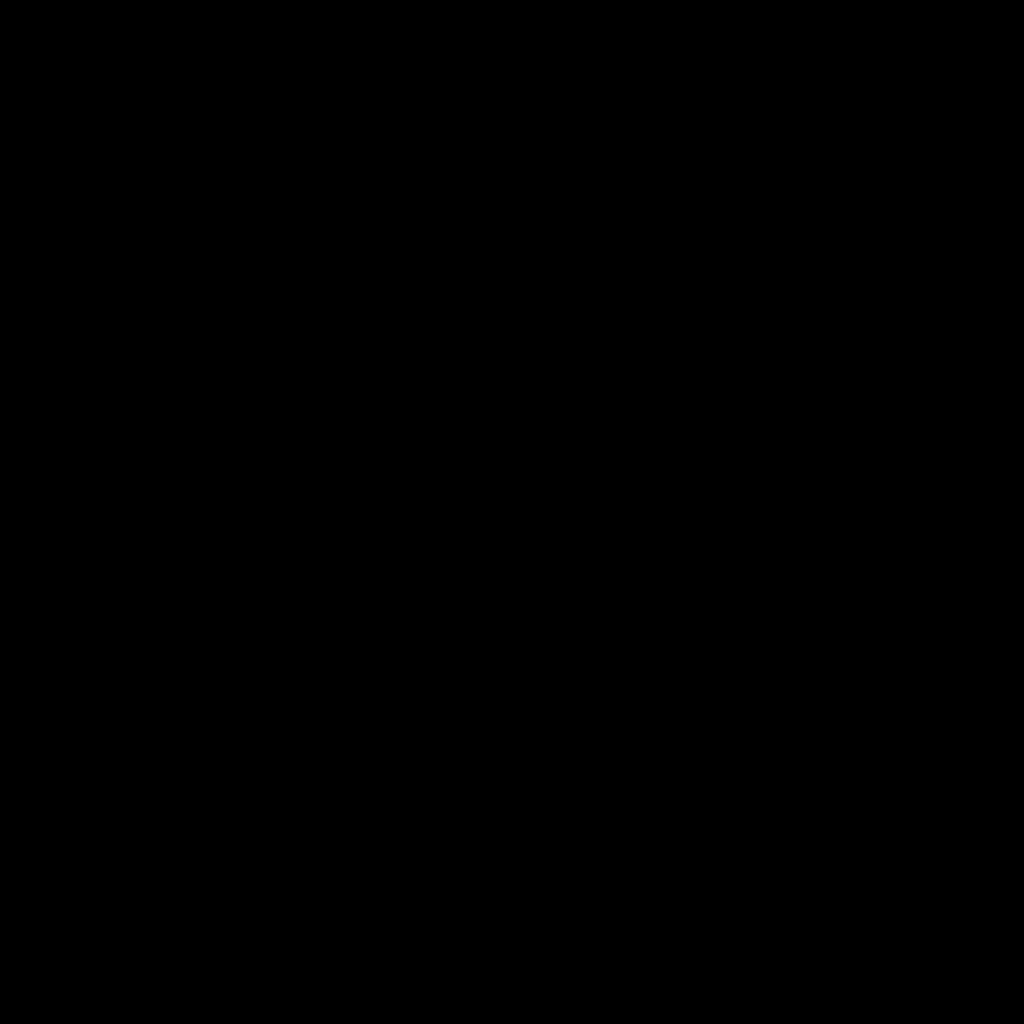

In [5]:
prompt = "highly detailed portrait photograph of an astronaut riding a horse on mars, cinematic lighting"
num_steps = 30

with torch.autocast(device.type):
    baseline = pipe(prompt, num_inference_steps=num_steps, guidance_scale=7.5).images[0]

baseline

In [6]:
class LatentDataset(Dataset):
    def __init__(self, latents):
        self.latents = latents

    def __len__(self):
        return len(self.latents)

    def __getitem__(self, idx):
        # ELS expects (tensor, label)
        return self.latents[idx].float(), torch.tensor(0)


# Collect a small latent set from SDXL itself (acts as empirical latent dataset)
latent_prompts = [
    "a cozy living room with a fireplace",
    "a futuristic cityscape at sunset",
    "a macro photo of a colorful insect",
    "a watercolor painting of mountains"
]

latent_samples = []
with torch.autocast(device.type):
    for p in latent_prompts:
        out = pipe(p, num_inference_steps=15, guidance_scale=7.0, output_type="latent")
        # `out.images` is latent batch when output_type="latent"
        latent = out.images[0].detach().to(device)
        latent_samples.append(latent)

latent_dataset = LatentDataset(latent_samples)
latent_shape = latent_samples[0].shape  # (4, H/8, W/8)
latent_shape

  0%|          | 0/15 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Build ELS over the SDXL latent space
im_h, im_w = latent_shape[-2:]
latent_backbone = LocalEquivBordersScoreModule(
    latent_dataset,
    image_size=im_h,
    channels=4,
    kernel_size=3,
    batch_size=2,
    schedule=cosine_noise_schedule,
    max_samples=16,
    shuffle=True,
)

latent_machine = ScheduledScoreMachine(
    latent_backbone,
    in_channels=4,
    imsize=im_h,
    default_time_steps=20,
    noise_schedule=cosine_noise_schedule,
    score_backbone=True,
)


In [ ]:
# Sample in latent space with ELS, then decode through SDXL VAE
with torch.autocast(device.type):
    z0 = torch.randn(1, *latent_shape, device=device)
    z_els = latent_machine(z0.clone(), device=device)

imgs = decode_latents(torch.cat([z0, z_els], dim=0)).cpu()

show_images(
    [imgs[0].permute(1, 2, 0), imgs[1].permute(1, 2, 0)],
    ["Gaussian latent decoded", "ELS-evolved latent decoded"],
)


In [ ]:
# Visual compare SDXL baseline vs ELS latent decode
show_images(
    [baseline, imgs[1].permute(1, 2, 0)],
    ["SDXL baseline (text-to-image)", "ELS latent decode (text-agnostic)"]
)


Notes / caveats:
- The ELS backbone here is built from a tiny latent dataset for demo purposes; increase `latent_prompts`, `max_samples`, and `default_time_steps` for better fidelity.
- If you have pretrained ELS scales/backbone tuned for SDXL latents, load them before sampling (e.g., via `torch.load` on the `latent_backbone` / `latent_machine` state_dicts).
- SDXL checkpoints may require a Hugging Face token; run `huggingface-cli login` beforehand if needed.
- Running on CPU will be extremely slow; prefer CUDA and 16-bit autocast as shown.
